<a href="https://colab.research.google.com/github/yiqi0806-collab/global-sensitivity-analysis/blob/main/test_for_GAS_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import numpy.random as R
from scipy.stats import qmc
from scipy.stats import norm
from scipy.stats import chi2
from scipy import stats
import random
import math
import matplotlib.pyplot as plt
from numpy.linalg import eig
%matplotlib inline

# Calculate the matrix B
def dFunc0(x,Func,M2,shiftedSobol=True,distribution='uniform'):    #rememebr to change distribution if not use shiftedSobol
    chi,dim = x.shape[0],x.shape[1]
    temp = np.zeros((dim,chi*M2))
    #print("55555",x)
    if(shiftedSobol == True):
        rand_add = qmc.Sobol(dim, scramble=False).random(M2+1)[1:]
        for i in range(M2):
            xe = np.tile(x.transpose(), dim).transpose()*(1-np.repeat(np.array(np.identity(dim)), chi, axis=0))
            if distribution == 'normal':
                rand = norm.ppf((norm.cdf(x)+rand_add[i])%1)
            elif distribution == 'uniform':
                rand = (x+rand_add[i])%1
            elif distribution =='chi_squared':
                rand1 = chi2.ppf((chi2.cdf(x[:,0],df=10)+rand_add[i][0])%1, df=10)
                rand2 = chi2.ppf((chi2.cdf(x[:,1],df=13.978)+rand_add[i][1])%1, df=13.978)
                rand = np.column_stack((rand1, rand2))
            #print("22222",rand)
            xe += rand.T.reshape(dim*chi,1)*np.repeat(np.array(np.identity(dim)), chi, axis=0)
            #print("11111",xe)
            #xe += rand.T * np.repeat(np.array(np.identity(dim)), chi, axis=0)
            print("55555",x.shape)
            print("66666",Func(xe).shape)
            print("77777",Func(x).shape)
            print("8888",np.tile(Func(x),dim).shape)
            temp[:,i*(chi):(i+1)*(chi)] = ((Func(xe)-np.tile(Func(x),dim))/np.sum(xe-np.tile(x.transpose(),dim).transpose(),axis=1)).reshape(dim,chi)

    else:
        for i in range(M2):
            xe = np.tile(x.transpose(), dim).transpose()*(1-np.repeat(np.array(np.identity(dim)), chi, axis=0))
            if distribution == 'normal':
                rand = R.normal(0,1,(chi,dim))
            elif distribution == 'uniform':
                rand = R.uniform(0,1,(chi,dim))
            xe += rand.T.reshape(dim*chi,1)*np.repeat(np.array(np.identity(dim)), chi, axis=0)
            temp[:,i*(chi):(i+1)*(chi)] = ((Func(xe)-np.tile(Func(x),dim))/np.sum(xe-np.tile(x.transpose(),dim).transpose(),axis=1)).reshape(dim,chi)

    return temp

# Calculate eigenvalue decomposition //Func in put is m*n matrix, where n is the dimension of x of f(x), m is how many sample to repeat for x 比如100*10 100个x 每个x是10dimension.
#                     output is m number of result f(x), it's a list.
def GAS(Func,dim,chi,M1,M2,shiftedSobol=True,distribution='uniform'):      #remember to change distribution
    if distribution == 'normal':
        z = R.normal(0, 1, (M1, dim))
    elif distribution == 'uniform':
        z = R.uniform(0, 1, (M1, dim))
    elif distribution == 'chi_squared':                 #special case for chi_squared
        x1_samples = R.chisquare(df=10, size=M1)
        x2_samples = R.chisquare(df=13.978, size=M1)
        z = np.column_stack((x1_samples, x2_samples))
    deriv = dFunc0(z,Func,M2,shiftedSobol,distribution=distribution)
    deriv /= np.sqrt(chi)
    u, s, vh = np.linalg.svd(deriv.astype(float), full_matrices=True)
    s = s**2
    return u, s



# Estimate the matrix Phi
def Phi_est(X, expo, coef, P):
    Num = X.shape[0]
    dim = X.shape[1]
    return np.dot(np.prod((np.tile(X, P)**expo.flatten()).reshape((Num*P, dim)),axis = 1).reshape((Num, P))
               ,np.array(coef)).T

def Funy(z,z1,u,Func):
    dim = u.shape[0]
    dim1 = z.shape[1]
    chi = z.shape[0]
    f1 = Func(np.dot(z,u[:,:dim1].transpose())+np.dot(z1,u[:,dim1:].transpose()))
    return f1

# Estimate k hat
def estimate_k_reg1(z,z1,u, exponents, coefficients, P, Func):
    phi = Phi_est(z, exponents, coefficients,P)
    khat = np.linalg.inv(phi @ np.transpose(phi)) @ phi @ Funy(z,z1,u,Func)
    return khat

# Estimate the expectation from PCE
def GAS_PCE(Func, Num_exp, z1, dim1, u, exponents, coefficients, P):
    PCE = np.zeros(Num_exp)
    for i in range(Num_exp):
        kii = estimate_k_reg1(z1[i][:,:dim1], z1[i][:,dim1:], u, exponents, coefficients, P, Func)
        PCE[i] = kii[0]
    return PCE

def GAS_score(m,u,s):                         #m is how many eigenvalue we use
  gas_score = u[:,:m]**2@s[:m]/sum(u[:,:m]**2@s[:m])
  return gas_score

#def Func(x):
#  x1=x[:, 0] + 0.1 * np.sum(np.sin(100 * x[:, 1:]), axis = 1)   #example 1
#  return x1

def Func(x):                                  #example 2
  x=x-0.5
  # Summation of i * x_i for i in range 1 to 10
  summation = sum(i * x[:,i-1] for i in range(1, 11))

  # Interaction term
  interaction = 10 * (x[:,0] * x[:,1] - x[:,8] * x[:,9])

  # Noise term from N(0, 1)
  noise = 1*R.normal(0,1,x.shape[0])
  # Final result
  return summation + interaction + noise

#def Func(x):
# x0=chi2.ppf(x[:,0], df=10)
#  x1=chi2.ppf(x[:,1], df=13.978)
#  y=x0/x1
#  return y


55555 (10000, 10)
66666 (100000,)
77777 (10000,)
8888 (100000,)
[[-5.08828286e-02  4.99100184e-01  8.56014037e-01  1.17000098e-01
   4.17946812e-02 -7.65737396e-03 -4.25043210e-03 -4.20679305e-03
  -2.51970024e-03  3.65340022e-03]
 [-1.03038916e-01 -8.54430818e-01  4.64005620e-01  1.54979305e-01
   1.39596015e-01 -2.36486424e-03 -1.04667246e-03  2.89527288e-04
  -2.09146920e-02 -8.93949761e-03]
 [-1.49090298e-01 -5.29542940e-03 -4.07098877e-03  2.33534813e-02
  -1.86336518e-01 -6.74540290e-01  6.53709881e-01 -1.71596668e-01
  -1.74634531e-01  1.33018134e-02]
 [-2.02607463e-01  7.42097121e-03 -3.77450225e-03  3.76921546e-02
  -2.48993220e-01  2.60829881e-01  9.57007643e-02  2.39167902e-01
  -4.95391353e-01 -7.18093194e-01]
 [-2.51949264e-01 -1.47159261e-02  6.32434225e-03  1.09930457e-02
  -2.63752801e-01 -2.79957438e-01 -1.27290155e-01  8.15990592e-01
   3.09194914e-01  1.02749861e-01]
 [-3.03513440e-01 -9.25302336e-03  3.89835465e-03  7.11741731e-03
  -2.85240714e-01  5.36838589e-01  

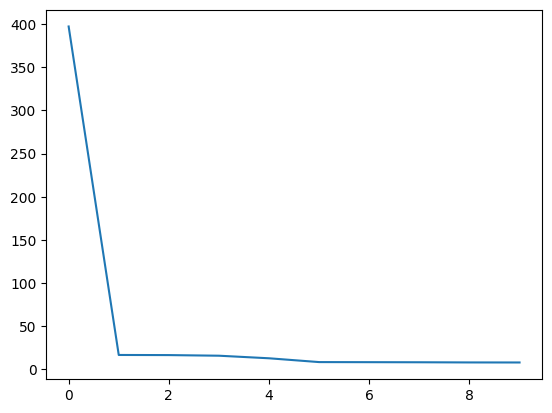

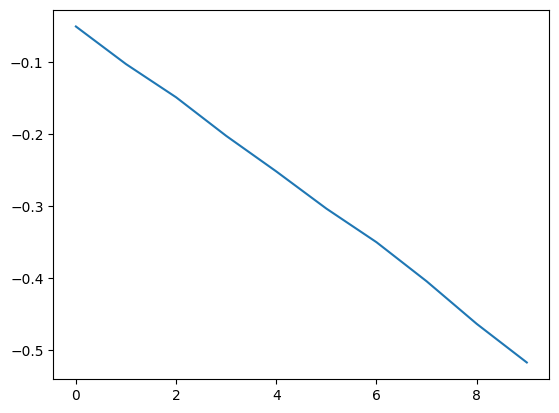

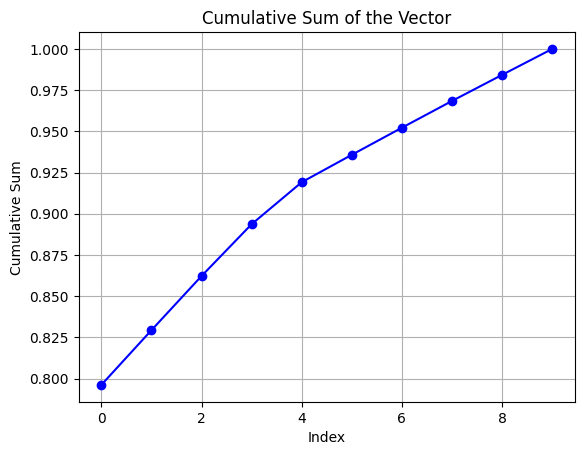

GAS_score is [0.0348996  0.04101224 0.03415425 0.04851576 0.06637973 0.08877074
 0.11298415 0.14472173 0.19452587 0.23403592]


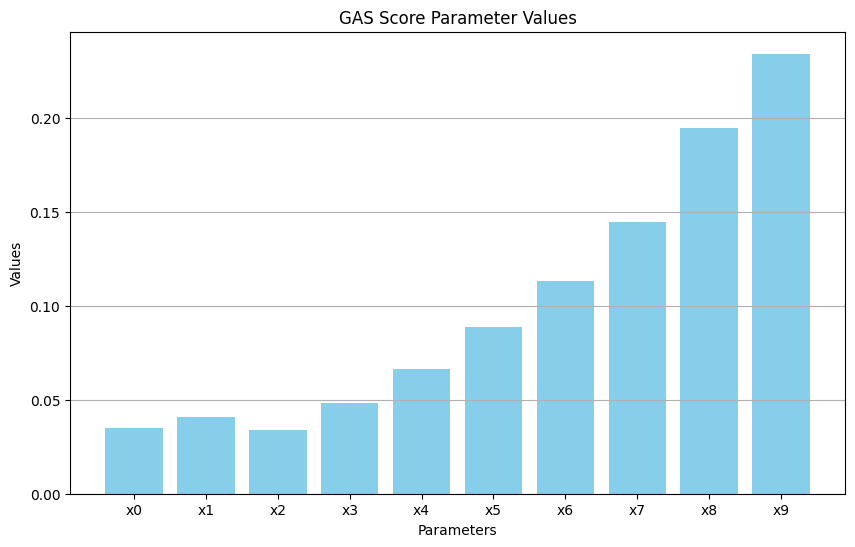

In [ ]:
dim=10
chi=10000
M1=10000
M2=1


u0, s0 = GAS(Func,dim,chi,M1,M2,shiftedSobol=True)
print(u0)
print(s0)
plt.plot(s0)
plt.show()

plt.plot(u0[:,0])
plt.show()

cumulative_sum = np.cumsum(s0)
cumulative_sum_percentage = (cumulative_sum / cumulative_sum[-1])
# Plot the cumulative sum
plt.plot(cumulative_sum_percentage, marker='o', linestyle='-', color='b')
plt.title("Cumulative Sum of the Vector")
plt.xlabel("Index")
plt.ylabel("Cumulative Sum")
plt.grid(True)
plt.show()

gas_values=GAS_score(10,u0,s0)
print("GAS_score is",gas_values)

#width = 0.4
#x = np.arange(1,dim+1)
#labels = x
#fig, ax4 = plt.subplots()
#rects1 = ax4.bar(x-width/2, GAS_score(10,u0,s0), width, label='GAS score with $m = 10$')
#rects2 = ax4.bar(x+width/2, GAS_score(5,u0,s0), width, label='GAS score with $m = 5$')
#ax4.set_ylabel('Sensitivities')
#ax4.set_xlabel('Inputs')
#ax4.set_xticks(x)
#ax4.set_xticklabels(labels)
# Add a legend
#ax4.legend()
# Show the plot
#plt.show()

parameters = ["x0", "x1", "x2", "x3", "x4", "x5", "x6", "x7","x8", "x9"]

# Plotting the histogram
plt.figure(figsize=(10, 6))
plt.bar(parameters, gas_values, color='skyblue')
plt.xlabel("Parameters")
plt.ylabel("Values")
plt.title("GAS Score Parameter Values")
plt.grid(axis='y')
plt.show()

In [ ]:
import numpy as np


# Example matrix A
A = np.array([[1, 2],
              [3, 4]])

# Compute eigenvalues and eigenvectors
eigenvalues, eigenvectors = np.linalg.eig(A)

# First eigenvector
first_eigenvector = eigenvectors[:, 1]

# Compute the transpose of the first eigenvector times the first eigenvector
result = np.outer(first_eigenvector, first_eigenvector)

# Alternatively, you can use matrix multiplication (in this case, it gives the same result)
# result = np.dot(first_eigenvector[:, np.newaxis], first_eigenvector[np.newaxis, :])

# Display the result
print(A[:,:2]**2@np.array([[2],[3]]))
print(eigenvalues)
print("First eigenvector:\n", first_eigenvector)
print("\nFirst eigenvector times its transpose (Outer product):\n", result)

0.82456484**2+0.56576746**2


[[14]
 [66]]
[-0.37228132  5.37228132]
First eigenvector:
 [-0.41597356 -0.90937671]

First eigenvector times its transpose (Outer product):
 [[0.173034   0.37827667]
 [0.37827667 0.826966  ]]


0.9999999941590771

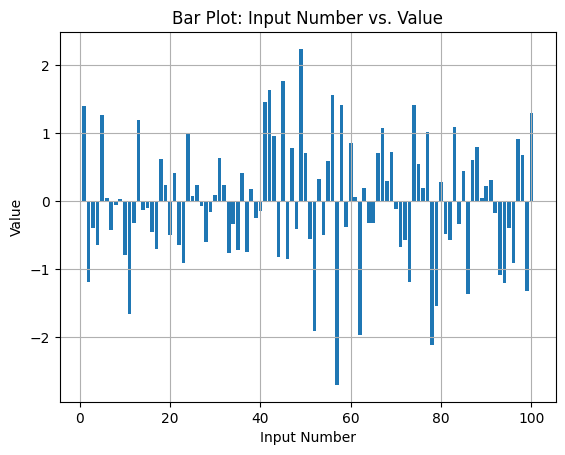

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Example data
data = np.random.randn(100)  # 100 random numbers

# Create x values representing the number of input (1 to 100)
x_values = np.arange(1, len(data) + 1)

# Create a bar plot: x is the input number, y is the value
plt.bar(x_values, data)

# Add title and labels
plt.title("Bar Plot: Input Number vs. Value")
plt.xlabel("Input Number")
plt.ylabel("Value")

# Show the plot
plt.grid(True)
plt.show()


In [ ]:
a1=s0[0]*u0[0][0]**2
print(a1)
a2=s0[0]*u0[0][1]**2
print(a2)
print(a1/(a1+a2))
print(a2/(a1+a2))

0.008054644151629832
0.0060775257074986025
0.5699509864316463
0.4300490135683536


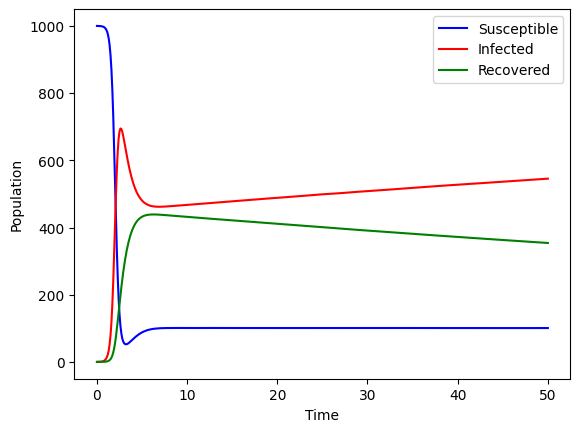

In [ ]:
from IPython import get_ipython
get_ipython().magic('reset -sf')
import numpy as np
import matplotlib.pyplot as pyplot
from scipy.integrate import odeint
from scipy.optimize import fsolve
from scipy.integrate import solve_ivp
import random
pyplot.close('all')

##Define the RHS of ODEs
#def f1(Y,t,params):
#    S,I,R=Y
#   k, gamma = params
#    return -k*S*I
#def f2(Y,t,params):
#    S,I,R=Y
#    k, gamma = params
#    return k*S*I-gamma*I
#def f3(Y,t,params):
#    S,I,R=Y
#    k, gamma = params
#    return gamma*I
#This uses the differential equation for I
#def rhs(Y,t,params):
#    S,I,R=Y
#    gamma, k, delta, r, N = params
#    return [f1(Y,t,params),f2(Y,t,params),f3(Y,t,params)]
# same as usual: define f and g, rhs returns the right hand side

#Define the RHS of ODEs
def f1(t,Y,params):
    S,I, R=Y
    k, gamma, alpha, N = params
    return -k*S*I+alpha*(N-S-I)+.5*R
def f2(t,Y,params):
    S,I, R=Y
    k, gamma, alpha, N  = params
    return k*S*I-gamma*I
def f3(t,Y,params):
    S,I,R=Y
    k, gamma, alpha, N = params
    return gamma*I-.5*R
def rhs(t,Y,params):
    S,I,R=Y
    k, gamma, alpha,N  = params
    return [f1(t,Y,params),f2(t,Y,params), f3(t,Y,params)]
# same as usual: define f and g, rhs returns the right hand side
# parameters are from the paper, beware the order though
p_names=( 'k','gamma')
params=np.array([ 0.005, 0.5, .01, 1000])
#Screening -- this is written inefficiently on purpose so that the
# steps are transparent. There are multiple examples of
#more efficient sampling: https://abe.ufl.edu/Faculty/jjones/ABE_5646/2010/Morris.1991%20SA%20paper.pdf
# for example.
#y0 = [100.35,1,0,0]
tspan = np.linspace(0, 50, 500)
yp= solve_ivp(lambda t,Y: rhs(t,Y,params), [tspan[0],tspan[-1]], [params[-1],.1,0], method='RK45',t_eval=tspan)
pyplot.figure(1)

pyplot.plot(tspan,yp.y[0],'b-')
pyplot.plot(tspan,yp.y[1],'r-')
pyplot.plot(tspan,params[-1]-yp.y[0]-yp.y[1],'g-')
pyplot.legend(['Susceptible','Infected','Recovered'])
pyplot.legend(['Susceptible','Infected','Recovered'])
pyplot.xlabel('Time')
pyplot.ylabel('Population')


pyplot.savefig('SIRS_0.jpg')

In [ ]:
import scipy.integrate as spi
import numpy as np

#x=[R_m,v,K,P,u,t]
def B(x):
  return (-x[:,0]+(x[:,0]**2+(2*x[:,1]*x[:,2]*x[:,3]*x[:,4]*x[:,6]/x[:,5]))**(0.5))/x[:,]

def J(x):
  return x[:,3]/(x[:,4]*())

<ipython-input-15-b48145452c5d>:24: DeprecationWarning: `salib.sample.saltelli` will be removed in SALib 1.5.1 Please use `salib.sample.sobol`
  param_values = saltelli.sample(problem, N, calc_second_order=True)
/usr/local/lib/python3.11/dist-packages/SALib/sample/saltelli.py:110: UserWarning: 
        Convergence properties of the Sobol' sequence is only valid if
        `N` (12000) is equal to `2^n`.
        
  warnings.warn(msg)
/usr/local/lib/python3.11/dist-packages/SALib/util/__init__.py:274: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  names = list(pd.unique(groups))


          ST   ST_conf
x0  0.544661  0.024140
x1  0.551365  0.030331
          S1   S1_conf
x0  0.452069  0.024936
x1  0.454519  0.029579
                S2   S2_conf
[x0, x1]  0.095628  0.059751


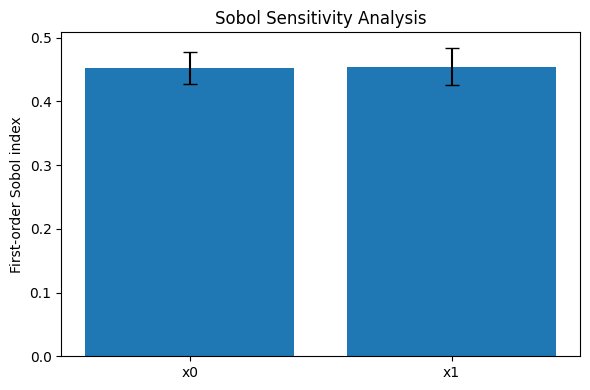

In [ ]:
import numpy as np
!pip install SALib
import SALib
from SALib.sample import saltelli
from SALib.analyze import sobol
import matplotlib.pyplot as plt

# Define the problem with uniform [0,1] inputs (will be transformed)
problem = {
    'num_vars': 2,
    'names': ['x0', 'x1'],
    'bounds': [[0, 1], [0, 1]]
}

# Define the model: transform inputs to chi-squared, then compute y
def model(X):
    x0 = chi2.ppf(X[:, 0], df=10)
    x1 = chi2.ppf(X[:, 1], df=13.978)
    y = x0 / x1
    return y

# Generate samples
N = 12000 # base sample size
param_values = saltelli.sample(problem, N, calc_second_order=True)

# Evaluate model
Y = model(param_values)

# Analyze Sobol indices
sobol_indices = sobol.analyze(problem, Y, calc_second_order=True, print_to_console=True)

# Plot first-order indices
plt.figure(figsize=(6, 4))
plt.bar(problem['names'], sobol_indices['S1'], yerr=sobol_indices['S1_conf'], capsize=5)
plt.ylabel('First-order Sobol index')
plt.title('Sobol Sensitivity Analysis')
plt.tight_layout()
plt.show()

Entropy-Based Sensitivity Indices:
x0: -0.2860
x1: -0.5972


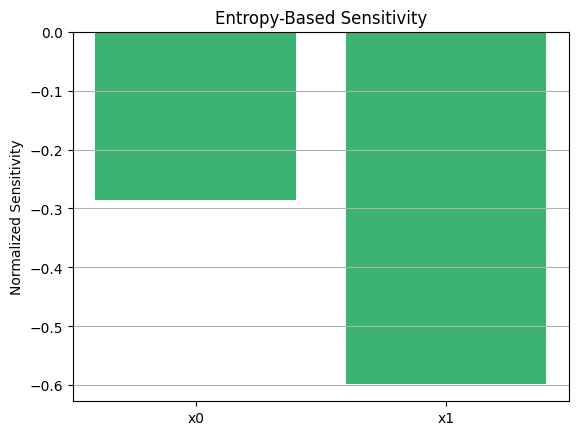

In [ ]:
import numpy as np
from scipy.stats import entropy
import matplotlib.pyplot as plt

def entropy_sensitivity_analysis(X, Y, bins=30):
    """
    Estimate entropy-based sensitivity indices.

    Parameters:
    - X: ndarray of shape (n_samples, n_features), input samples
    - Y: ndarray of shape (n_samples,), model outputs
    - bins: int, number of bins to discretize variables for entropy

    Returns:
    - sensitivities: list of entropy-based sensitivity indices
    """
    n_features = X.shape[1]
    sensitivities = []

    # Discretize output Y
    p_y, _ = np.histogram(Y, bins=bins, density=True)
    H_Y = entropy(p_y + 1e-12)  # Add small value to avoid log(0)

    for i in range(n_features):
        # Discretize Xi into bins
        p_xi, edges = np.histogram(X[:, i], bins=bins, density=False)
        edges[-1] += 1e-6  # Fix edge case
        H_Y_given_Xi = 0.0

        for j in range(bins):
            # Get Y values where Xi is in the j-th bin
            mask = (X[:, i] >= edges[j]) & (X[:, i] < edges[j+1])
            if np.sum(mask) == 0:
                continue
            p_y_given_xi, _ = np.histogram(Y[mask], bins=bins, density=True)
            H_y_given_xi = entropy(p_y_given_xi + 1e-12)
            weight = np.sum(mask) / len(X)
            H_Y_given_Xi += weight * H_y_given_xi

        sensitivity = (H_Y - H_Y_given_Xi) / H_Y  # Normalized
        sensitivities.append(sensitivity)

    return np.array(sensitivities)

N = 50000
X = np.random.rand(N, 2)
X[:, 0] = chi2.ppf(X[:, 0], df=10)
X[:, 1] = chi2.ppf(X[:, 1], df=13.978)

# Define model output
Y = X[:, 0] / X[:, 1]

# Run entropy-based sensitivity analysis
S_entropy = entropy_sensitivity_analysis(X, Y, bins=30)

# Print results
print("Entropy-Based Sensitivity Indices:")
print(f"x0: {S_entropy[0]:.4f}")
print(f"x1: {S_entropy[1]:.4f}")

# Plot
plt.bar(["x0", "x1"], S_entropy, color='mediumseagreen')
plt.title("Entropy-Based Sensitivity")
plt.ylabel("Normalized Sensitivity")
plt.grid(axis='y')
plt.show()